In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import plotly.express as px

In [2]:
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

FIG_DIR = Path('../figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name, dpi=300):
    fig.savefig(f"{FIG_DIR}/{name}", dpi=dpi, bbox_inches='tight')

In [3]:
# Load data
path = '../data/data_merged.parquet'
df = pd.read_parquet(path).copy()

# Date fields
for c in ['approvaldate', 'firstdisbursementdate', 'chargeoffdate', 'paidinfulldate', 'asofdate']:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors='coerce')

# Default event definition (default if any condition is met)
chargeoff_amt = pd.to_numeric(df.get('grosschargeoffamount'), errors='coerce').fillna(0)
loan_status = df.get('loanstatus').astype(str).str.upper()

df['default_event'] = (loan_status == 'CHGOFF').astype(int)

# Derived fields
df['approval_year'] = df['approvaldate'].dt.year
df['approval_month'] = df['approvaldate'].dt.to_period('M').dt.to_timestamp()
df['loan_amount'] = pd.to_numeric(df['grossapproval'], errors='coerce')
df['naics2'] = df['naicscode'].astype(str).str.extract(r'(\d{2})')[0]

df['business_age'] = df['businessage'].astype(str).str.strip()
df['business_type'] = df['businesstype'].astype(str).str.strip()
df['state'] = df['borrstate'].astype(str).str.strip().str.upper()

print('Data shape:', df.shape)
print('Approval year span:', int(df['approval_year'].min()), 'to', int(df['approval_year'].max()))
print('Overall default rate: {:.2%}'.format(df['default_event'].mean()))

Data shape: (183914, 56)
Approval year span: 1991 to 2025
Overall default rate: 6.58%


In [4]:
# Data overview
summary = {
    'n_loans': len(df),
    'n_states': df['state'].nunique(),
    'n_naics2': df['naics2'].nunique(),
    'default_rate': df['default_event'].mean(),
    'median_loan_amount': df['loan_amount'].median(),
    'missing_loan_amount': df['loan_amount'].isna().mean(),
}

pd.Series(summary).to_frame('value')

,value
n_loans,183914.000000
n_states,54.000000
n_naics2,22.000000
default_rate,0.065754
median_loan_amount,411000.000000
missing_loan_amount,0.000000


### Annual default rate time series

Compute default rate by `approval_year` and examine:
- 2007-09 global financial crisis period
- 2020 COVID shock
- long-run (34-year) trend

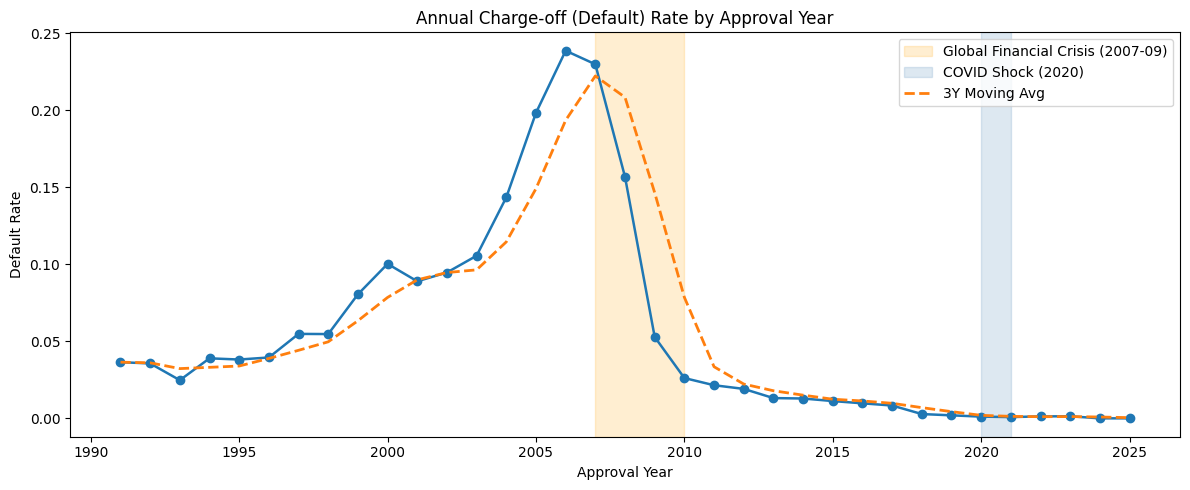

,approval_year,default_rate,n,default_rate_ma3
25,2016,0.009752,5127,0.011284
26,2017,0.008324,5166,0.009765
27,2018,0.002784,5029,0.006953
28,2019,0.001946,5653,0.004351
29,2020,0.001113,6289,0.001948
30,2021,0.000810,8638,0.001290
31,2022,0.001266,6318,0.001063
32,2023,0.001345,4460,0.001141
33,2024,0.000000,4023,0.000871
34,2025,0.000000,2140,0.000448


In [5]:
annual = (
    df.dropna(subset=['approval_year'])
      .groupby('approval_year', as_index=False)
      .agg(default_rate=('default_event', 'mean'), n=('default_event', 'size'))
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(annual['approval_year'], annual['default_rate'], marker='o', linewidth=1.8)
ax.set_title('Annual Charge-off (Default) Rate by Approval Year')
ax.set_xlabel('Approval Year')
ax.set_ylabel('Default Rate')

# Crisis-period highlighting
ax.axvspan(2007, 2009.99, alpha=0.18, color='orange', label='Global Financial Crisis (2007-09)')
ax.axvspan(2020, 2020.99, alpha=0.18, color='steelblue', label='COVID Shock (2020)')

# 3-year moving average for long-run trend
annual['default_rate_ma3'] = annual['default_rate'].rolling(3, min_periods=1).mean()
ax.plot(annual['approval_year'], annual['default_rate_ma3'], linestyle='--', linewidth=2, label='3Y Moving Avg')

ax.legend(loc='upper right')
plt.tight_layout()
save_fig(fig, 'eda_annual_default_rate.png')
plt.show()

annual.tail(10)

### Segmentation by loan amount

We use a discrete-time approximation:
- `duration_month`: months from origination to termination / observation time
- `hazard_t = P(default at t | survive to t)`

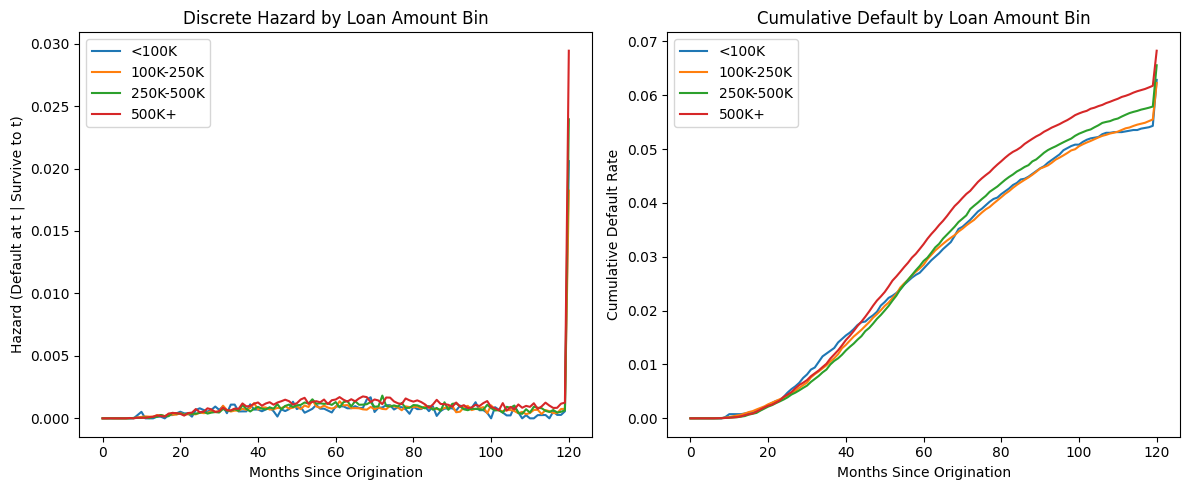

,count,default_rate
loan_amount_bin,,
<100K,7733,0.062848
100K-250K,45587,0.062277
250K-500K,54285,0.065561
500K+,76309,0.068262


In [6]:
# Loan-amount buckets
bins = [0, 100_000, 250_000, 500_000, np.inf]
labels = ['<100K', '100K-250K', '250K-500K', '500K+']
df['loan_amount_bin'] = pd.cut(df['loan_amount'], bins=bins, labels=labels, include_lowest=True)

# Survival duration (months)
start_date = df['firstdisbursementdate'].fillna(df['approvaldate'])
end_date = df['chargeoffdate'].where(df['default_event'].eq(1), df['paidinfulldate'])
end_date = end_date.fillna(df['asofdate'])

duration_month = ((end_date - start_date).dt.days / 30.44).clip(lower=0)
work = df[['default_event', 'loan_amount_bin']].copy()
work['duration_month'] = duration_month
work = work.dropna(subset=['loan_amount_bin', 'duration_month'])
work['dur_int'] = np.floor(work['duration_month']).astype(int)

# Cap at 120 months (10 years) to reduce extreme-tail noise
max_m = 120
work['dur_cap'] = work['dur_int'].clip(upper=max_m)

hazard_rows = []
cum_rows = []

for b in labels:
    sub = work[work['loan_amount_bin'].astype(str) == b]
    if len(sub) == 0:
        continue

    dur_counts = sub['dur_cap'].value_counts().sort_index().reindex(range(max_m + 1), fill_value=0)
    at_risk = dur_counts.iloc[::-1].cumsum().iloc[::-1]

    default_counts = (
        sub.loc[sub['default_event'] == 1, 'dur_cap']
           .value_counts()
           .sort_index()
           .reindex(range(max_m + 1), fill_value=0)
    )

    hazard = (default_counts / at_risk).replace([np.inf, -np.inf], np.nan).fillna(0)

    # Cumulative default share up to time t
    cum_default = default_counts.cumsum() / len(sub)

    for t in range(max_m + 1):
        hazard_rows.append((b, t, float(hazard.iloc[t])))
        cum_rows.append((b, t, float(cum_default.iloc[t])))

haz_df = pd.DataFrame(hazard_rows, columns=['loan_amount_bin', 'month', 'hazard'])
cum_df = pd.DataFrame(cum_rows, columns=['loan_amount_bin', 'month', 'cum_default'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for b in labels:
    s1 = haz_df[haz_df['loan_amount_bin'] == b]
    axes[0].plot(s1['month'], s1['hazard'], label=b)
axes[0].set_title('Discrete Hazard by Loan Amount Bin')
axes[0].set_xlabel('Months Since Origination')
axes[0].set_ylabel('Hazard (Default at t | Survive to t)')
axes[0].legend()

for b in labels:
    s2 = cum_df[cum_df['loan_amount_bin'] == b]
    axes[1].plot(s2['month'], s2['cum_default'], label=b)
axes[1].set_title('Cumulative Default by Loan Amount Bin')
axes[1].set_xlabel('Months Since Origination')
axes[1].set_ylabel('Cumulative Default Rate')
axes[1].legend()

plt.tight_layout()
save_fig(fig, 'eda_loan_amount_hazard_and_cum_default.png')
plt.show()

work.groupby('loan_amount_bin')['default_event'].agg(['count', 'mean']).rename(columns={'mean': 'default_rate'})

### By NAICS sector (two-digit)

- Build a two-digit NAICS default-rate heatmap (year x sector)
- Note: the chart keeps only the largest sectors by sample size to reduce small-sample noise.

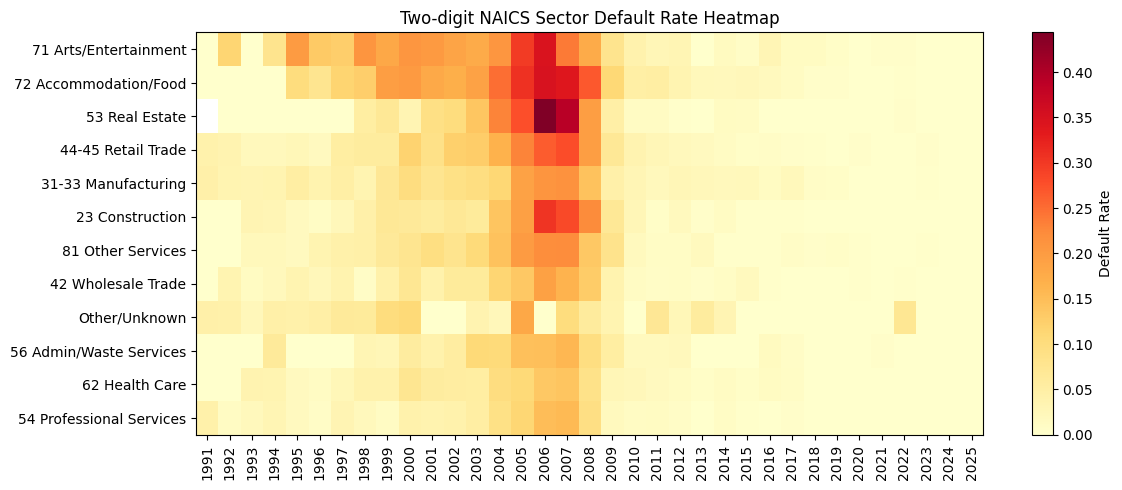

,count,mean
sector_2d,,
72 Accommodation/Food,22694,0.120296
71 Arts/Entertainment,4499,0.097577
44-45 Retail Trade,20906,0.081508
52 Finance/Insurance,2904,0.079545
51 Information,1356,0.070796
53 Real Estate,4152,0.068642
11 Agriculture,1044,0.067050
31-33 Manufacturing,21156,0.065561
23 Construction,12197,0.062146


In [7]:
naics_name = {
    '11': '11 Agriculture',
    '22': '22 Utilities',
    '23': '23 Construction',
    '31': '31-33 Manufacturing', '32': '31-33 Manufacturing', '33': '31-33 Manufacturing',
    '42': '42 Wholesale Trade',
    '44': '44-45 Retail Trade', '45': '44-45 Retail Trade',
    '48': '48-49 Transportation/Warehouse', '49': '48-49 Transportation/Warehouse',
    '51': '51 Information',
    '52': '52 Finance/Insurance',
    '53': '53 Real Estate',
    '54': '54 Professional Services',
    '56': '56 Admin/Waste Services',
    '61': '61 Education',
    '62': '62 Health Care',
    '71': '71 Arts/Entertainment',
    '72': '72 Accommodation/Food',
    '81': '81 Other Services',
}

df['sector_2d'] = df['naics2'].map(naics_name).fillna('Other/Unknown')

# Show only the top 12 sectors by sample size
sector_counts = df['sector_2d'].value_counts()
keep_sectors = sector_counts.head(12).index

heat_df = df[df['sector_2d'].isin(keep_sectors)].dropna(subset=['approval_year']).copy()
heat_df['approval_year'] = heat_df['approval_year'].astype(int)

pivot = (
    heat_df.groupby(['sector_2d', 'approval_year'])['default_event']
           .mean()
           .unstack(fill_value=np.nan)
)

# Sort by average default rate to highlight high-risk sectors
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
ax.set_title('Two-digit NAICS Sector Default Rate Heatmap')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns.astype(int), rotation=90)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Default Rate')

plt.tight_layout()
save_fig(fig, 'eda_naics2_default_heatmap.png')
plt.show()

sector_rank = (
    df.groupby('sector_2d')['default_event']
      .agg(['count', 'mean'])
      .sort_values('mean', ascending=False)
)
sector_rank.head(10)

### By borrower state

- U.S. state-level average default-rate.

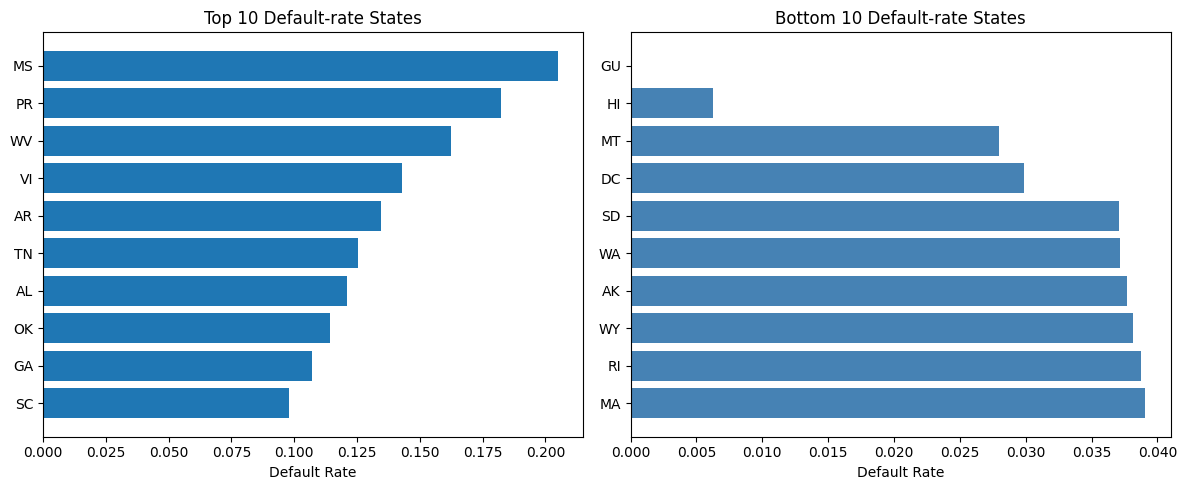

,state,default_rate,n
26,MS,0.204878,410
40,PR,0.182512,1441
52,WV,0.162338,154
48,VI,0.142857,7
2,AR,0.134647,609
44,TN,0.125586,1067
1,AL,0.121035,2396
37,OK,0.114374,1294
10,GA,0.107166,4731
42,SC,0.097909,1052


In [8]:
state_df = df.groupby('state', as_index=False).agg(default_rate=('default_event', 'mean'), n=('default_event', 'size'))

# Keep valid two-letter state codes only
state_df = state_df[state_df['state'].str.match(r'^[A-Z]{2}$', na=False)]

fig = px.choropleth(
    state_df,
    locations='state',
    locationmode='USA-states',
    color='default_rate',
    scope='usa',
    hover_data=['n'],
    color_continuous_scale='YlOrRd',
    title='Average Charge-off Rate by Borrower State'
)
fig.update_layout(
    paper_bgcolor='white',
    plot_bgcolor='white',
    geo=dict(bgcolor='white')
)
fig.write_html(FIG_DIR / 'eda_state_default_choropleth.html')
try:
    fig.write_image(FIG_DIR / 'eda_state_default_choropleth.png')
except Exception:
    pass
fig.show()

top10 = state_df.sort_values('default_rate', ascending=False).head(10)
bot10 = state_df.sort_values('default_rate', ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(top10['state'], top10['default_rate'])
axes[0].invert_yaxis()
axes[0].set_title('Top 10 Default-rate States')
axes[0].set_xlabel('Default Rate')

axes[1].barh(bot10['state'], bot10['default_rate'], color='steelblue')
axes[1].invert_yaxis()
axes[1].set_title('Bottom 10 Default-rate States')
axes[1].set_xlabel('Default Rate')

plt.tight_layout()
save_fig(fig, 'eda_state_default_rate_top_bottom_bar.png')
plt.show()

state_df.sort_values('default_rate', ascending=False).head(10)

### Business age and type

- default-rate differences between newer and established firms
- default-rate differences across `INDIVIDUAL` / `CORPORATION` / `PARTNERSHIP`

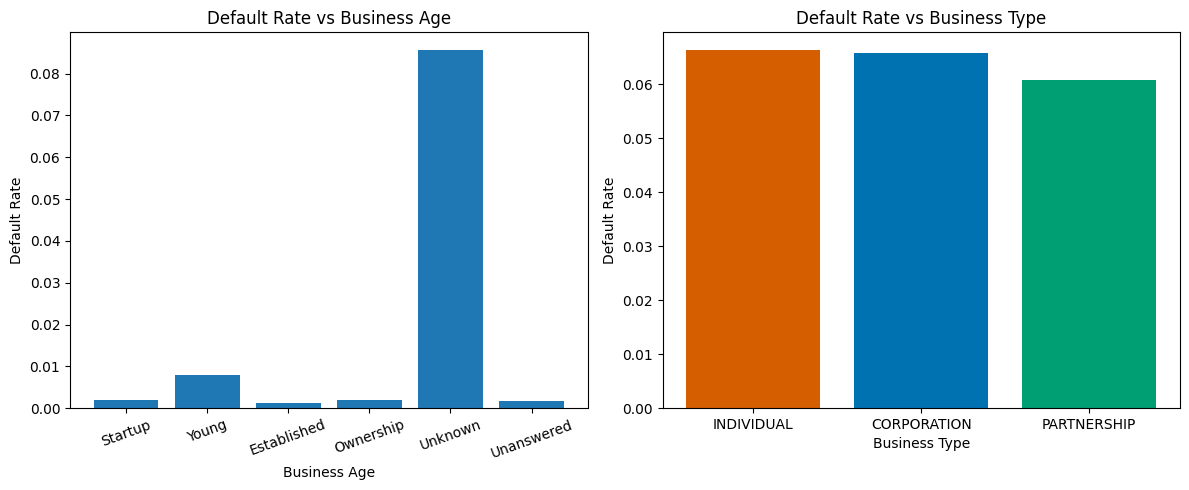

Business age stats:


,business_age,default_rate,n
4,Unknown,0.085612,140518
5,Young,0.007823,767
1,Ownership,0.001903,1051
2,Startup,0.001866,4822
3,Unanswered,0.001736,576
0,Established,0.001244,36180



Business type stats:


,business_type,default_rate,n
1,INDIVIDUAL,0.066278,17819
0,CORPORATION,0.065811,160323
2,PARTNERSHIP,0.060767,5266


In [9]:
# Business age
age_order = ['Startup', 'Young', 'Established', 'Ownership', 'Unknown', 'Unanswered']
age_df = df.groupby('business_age', as_index=False).agg(default_rate=('default_event', 'mean'), n=('default_event', 'size'))
age_df = age_df.sort_values('default_rate', ascending=False)

# Business type (keep major categories)
keep_types = ['INDIVIDUAL', 'CORPORATION', 'PARTNERSHIP']
type_df = (
    df[df['business_type'].isin(keep_types)]
      .groupby('business_type', as_index=False)
      .agg(default_rate=('default_event', 'mean'), n=('default_event', 'size'))
      .sort_values('default_rate', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Business age
plot_age = age_df.copy()
plot_age['business_age'] = pd.Categorical(plot_age['business_age'], categories=age_order, ordered=True)
plot_age = plot_age.sort_values('business_age')
axes[0].bar(plot_age['business_age'].astype(str), plot_age['default_rate'])
axes[0].set_title('Default Rate vs Business Age')
axes[0].set_xlabel('Business Age')
axes[0].set_ylabel('Default Rate')
axes[0].tick_params(axis='x', rotation=20)

# Business type
axes[1].bar(type_df['business_type'], type_df['default_rate'], color=['#D55E00', '#0072B2', '#009E73'])
axes[1].set_title('Default Rate vs Business Type')
axes[1].set_xlabel('Business Type')
axes[1].set_ylabel('Default Rate')

plt.tight_layout()
save_fig(fig, 'eda_business_age_and_type_default_rate.png')
plt.show()

print('Business age stats:')
display(age_df)
print('\nBusiness type stats:')
display(type_df)

### Macro indicators and loan default rate (preliminary analysis)

1. Build a monthly default-rate series (by `approval_month`)
2. Compare with macro variables at the same frequency (standardized in one chart)
3. Compute correlation matrix and lead-lag correlation (macro leads by 0-12 months)

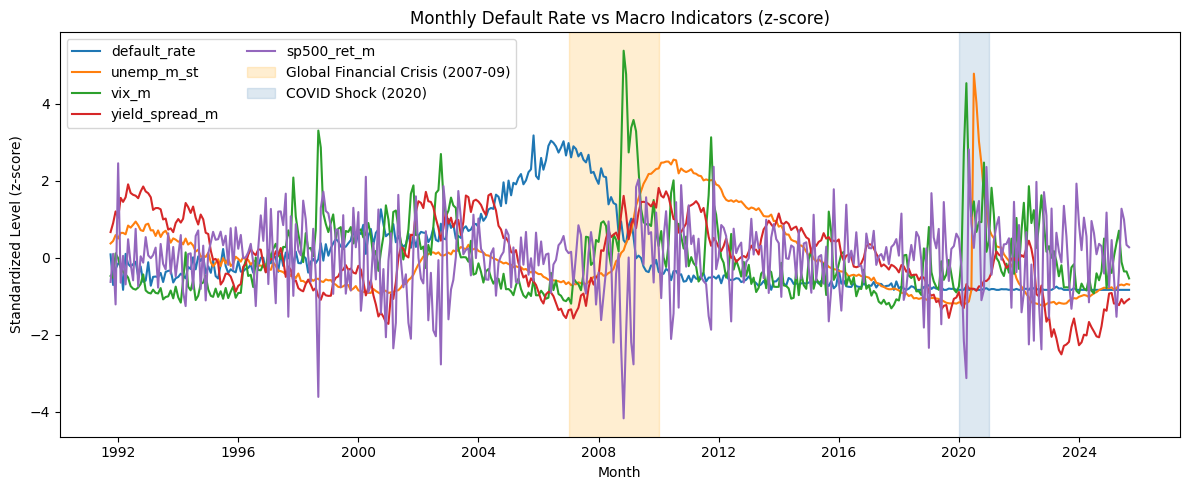

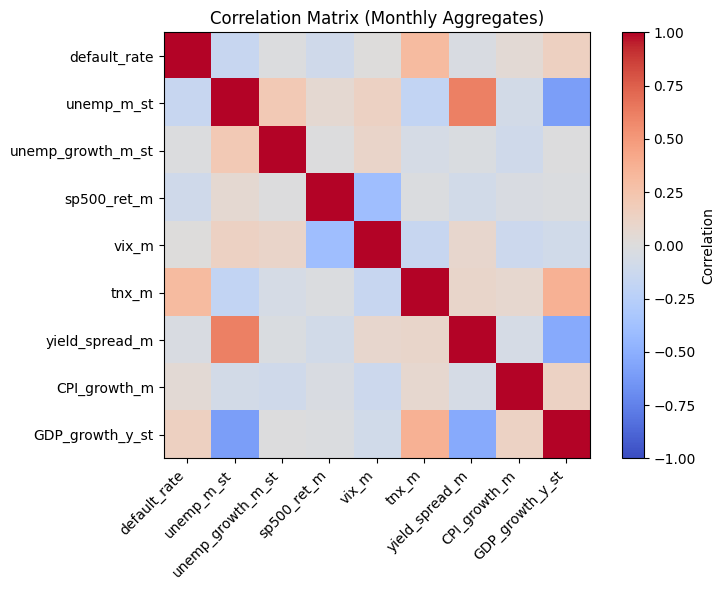

In [10]:
macro_cols = [
    'unemp_m_st', 'unemp_growth_m_st',
    'sp500_ret_m', 'vix_m', 'tnx_m', 'yield_spread_m',
    'CPI_growth_m', 'GDP_growth_y_st'
]
existing_macro = [c for c in macro_cols if c in df.columns]

monthly = (
    df.dropna(subset=['approval_month'])
      .groupby('approval_month', as_index=False)
      .agg(default_rate=('default_event', 'mean'), n=('default_event', 'size'),
           **{c: (c, 'mean') for c in existing_macro})
      .sort_values('approval_month')
)

# Standardized plotting
def zscore(x):
    s = x.std(ddof=0)
    if s == 0 or pd.isna(s):
        return x * np.nan
    return (x - x.mean()) / s

plot_cols = ['default_rate'] + [c for c in ['unemp_m_st', 'vix_m', 'yield_spread_m', 'sp500_ret_m'] if c in monthly.columns]

fig, ax = plt.subplots(figsize=(12, 5))
for c in plot_cols:
    ax.plot(monthly['approval_month'], zscore(monthly[c]), label=c, linewidth=1.5)
# Crisis-period highlighting
ax.axvspan(pd.Timestamp('2007-01-01'), pd.Timestamp('2009-12-31'), alpha=0.18, color='orange', label='Global Financial Crisis (2007-09)')
ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2020-12-31'), alpha=0.18, color='steelblue', label='COVID Shock (2020)')
ax.set_title('Monthly Default Rate vs Macro Indicators (z-score)')
ax.set_xlabel('Month')
ax.set_ylabel('Standardized Level (z-score)')
ax.legend(ncol=2)
plt.tight_layout()
save_fig(fig, 'eda_macro_vs_default_zscore_timeseries.png')
plt.show()

# Contemporaneous correlation
corr_cols = ['default_rate'] + existing_macro
corr = monthly[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title('Correlation Matrix (Monthly Aggregates)')
plt.colorbar(im, ax=ax, label='Correlation')
plt.tight_layout()
save_fig(fig, 'eda_macro_default_correlation_matrix.png')
plt.show()